# load

In [1]:
import os
dataset_path = r"C:\Users\anitt\OneDrive\Desktop\dl project\tomato\train"
print("Dataset Path:", dataset_path)

if os.path.exists(dataset_path):
    print("✅ Dataset loaded successfully!")
else:
    print("❌ Dataset path not found. Please check the path.")

Dataset Path: C:\Users\anitt\OneDrive\Desktop\dl project\tomato\train
✅ Dataset loaded successfully!


# total classes

In [2]:
class_names = sorted(os.listdir(dataset_path))

print("Total Classes:", len(class_names))
print("\nClass Names:\n")

for i, class_name in enumerate(class_names, start=1):
    print(f"{i}. {class_name}")

Total Classes: 10

Class Names:

1. Tomato___Bacterial_spot
2. Tomato___Early_blight
3. Tomato___Late_blight
4. Tomato___Leaf_Mold
5. Tomato___Septoria_leaf_spot
6. Tomato___Spider_mites Two-spotted_spider_mite
7. Tomato___Target_Spot
8. Tomato___Tomato_Yellow_Leaf_Curl_Virus
9. Tomato___Tomato_mosaic_virus
10. Tomato___healthy


# image count

In [3]:
image_count = {}

for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)
    image_count[class_name] = len(os.listdir(class_path))

print("Number of Images in Each Class:\n")

for class_name, count in image_count.items():
    print(f"{class_name}: {count}")

Number of Images in Each Class:

Tomato___Bacterial_spot: 1000
Tomato___Early_blight: 1000
Tomato___Late_blight: 1000
Tomato___Leaf_Mold: 1000
Tomato___Septoria_leaf_spot: 1000
Tomato___Spider_mites Two-spotted_spider_mite: 1000
Tomato___Target_Spot: 1000
Tomato___Tomato_Yellow_Leaf_Curl_Virus: 1000
Tomato___Tomato_mosaic_virus: 1000
Tomato___healthy: 1000


# bar graph

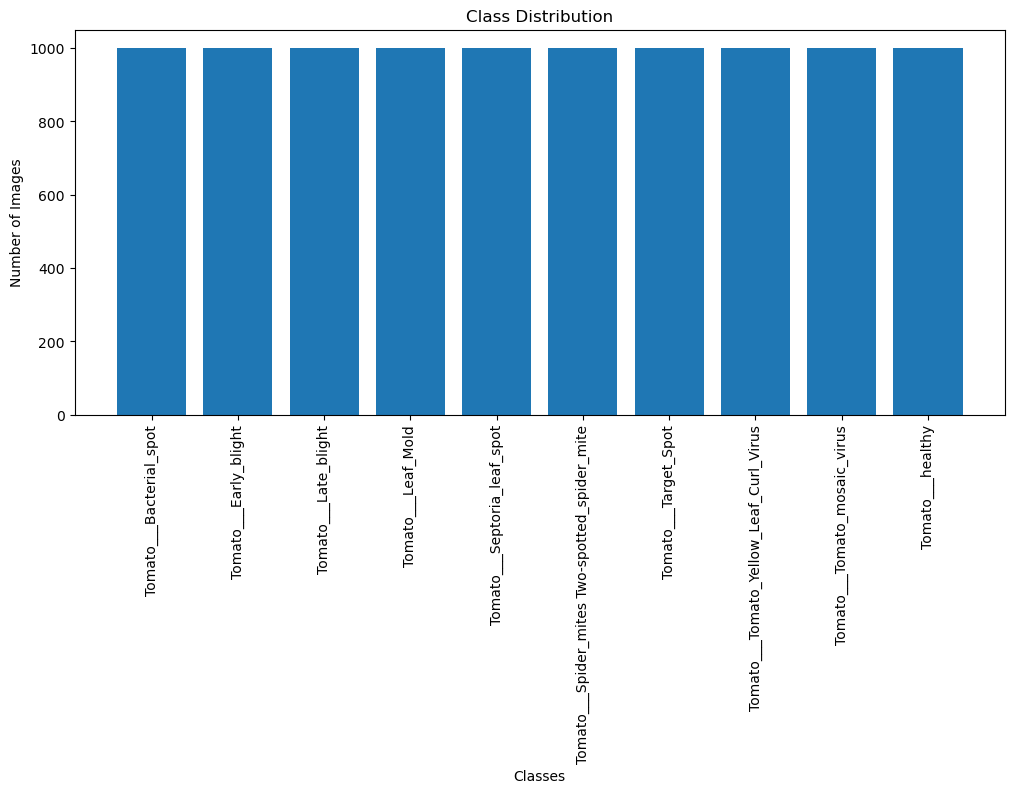

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.bar(image_count.keys(), image_count.values())

plt.xticks(rotation=90)

plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution")

plt.show()

# sample image from each class

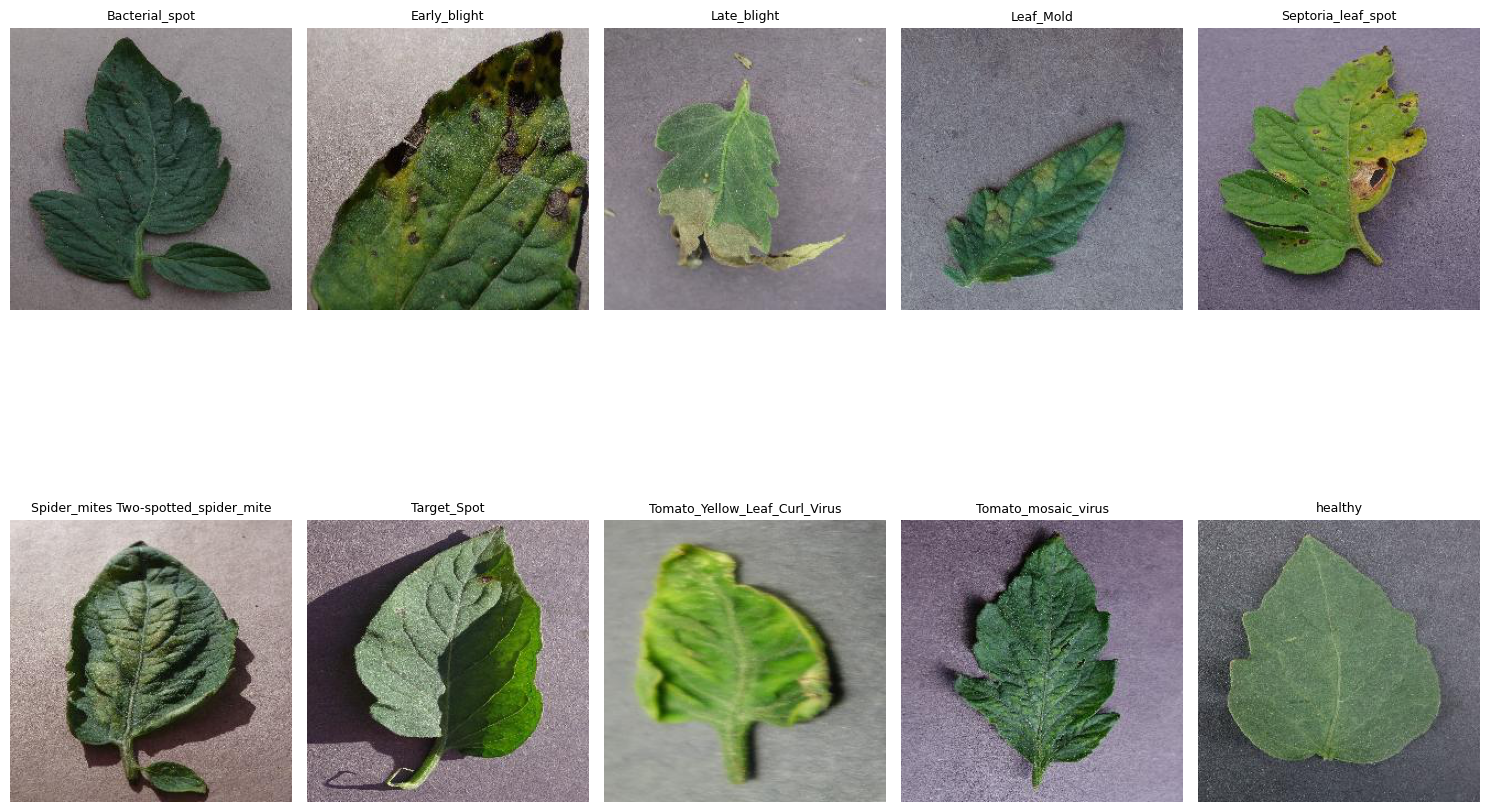

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

plt.figure(figsize=(15, 12))

for i, class_name in enumerate(class_names):
    class_path = os.path.join(dataset_path, class_name)

    image_name = os.listdir(class_path)[0]  # First image in the folder
    image_path = os.path.join(class_path, image_name)

    img = mpimg.imread(image_path)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(class_name.replace("Tomato___", ""), fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

# resize

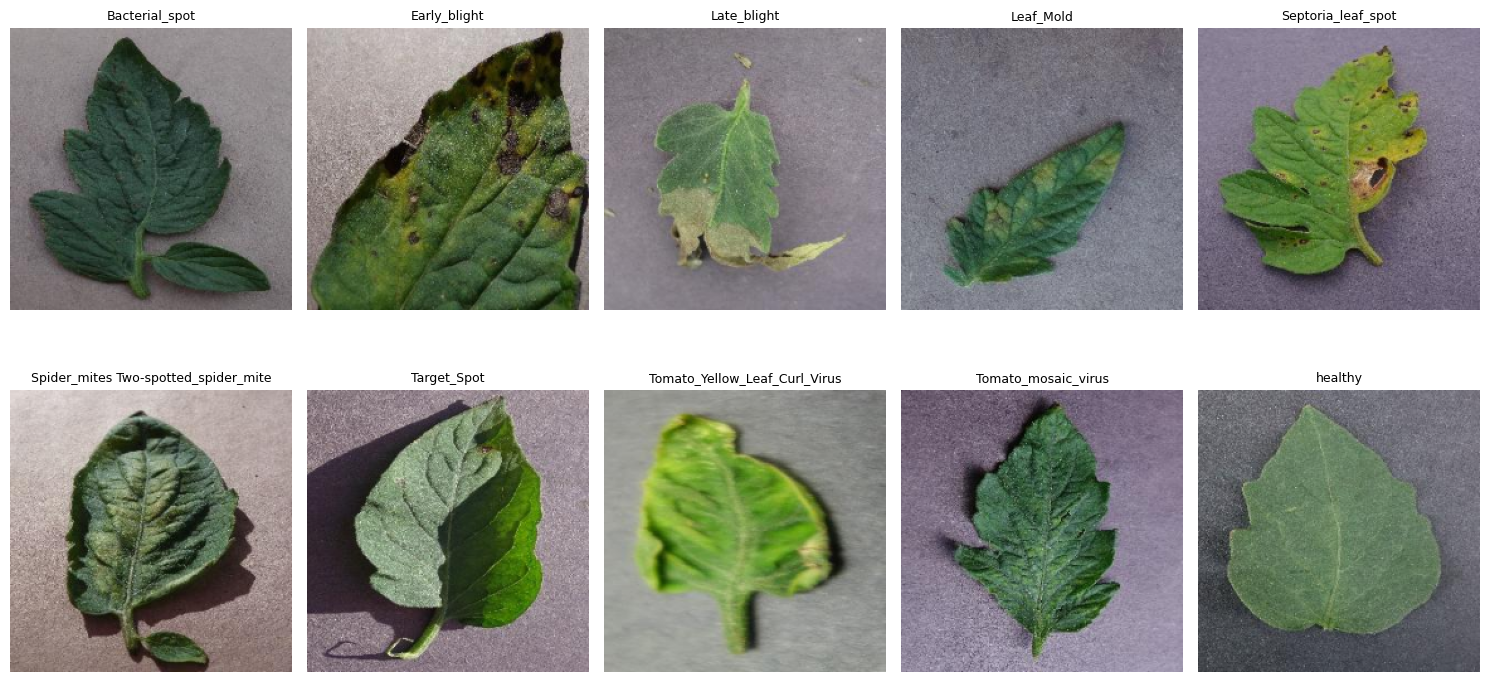

In [6]:
import cv2
import os
import matplotlib.pyplot as plt

IMG_SIZE = (224, 224)

plt.figure(figsize=(15, 8))

for i, class_name in enumerate(class_names):
    class_path = os.path.join(dataset_path, class_name)

    image_name = os.listdir(class_path)[0]   # First image
    image_path = os.path.join(class_path, image_name)

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize
    resized_img = cv2.resize(img, IMG_SIZE)

    plt.subplot(2, 5, i + 1)
    plt.imshow(resized_img)
    plt.title(class_name.replace("Tomato___", ""), fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

# median filter

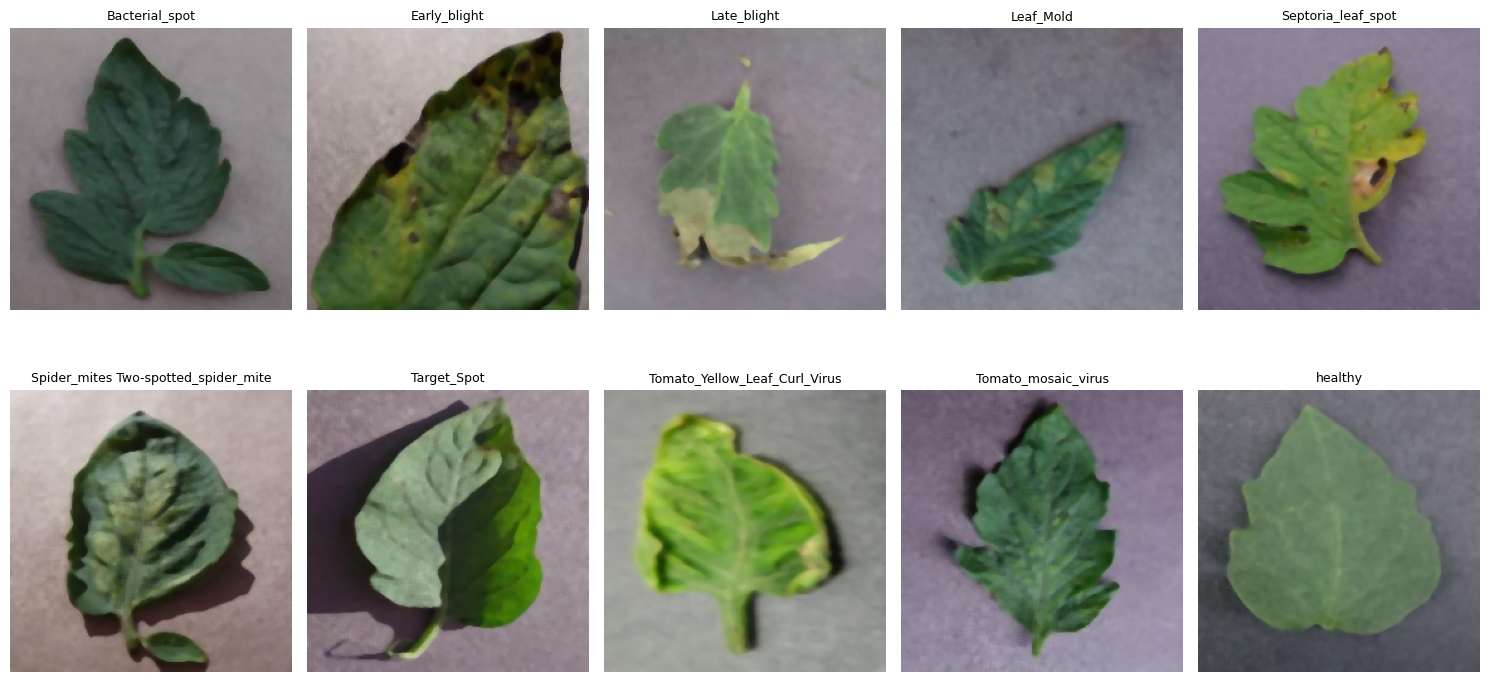

In [7]:
import cv2
import os
import matplotlib.pyplot as plt

IMG_SIZE = (224, 224)

plt.figure(figsize=(15,8))

for i, class_name in enumerate(class_names):

    class_path = os.path.join(dataset_path, class_name)
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    # Read image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize
    resized_img = cv2.resize(img, IMG_SIZE)

    # Apply Median Filter
    filtered_img = cv2.medianBlur(resized_img, 5)

    # Display
    plt.subplot(2,5,i+1)
    plt.imshow(filtered_img)
    plt.title(class_name.replace("Tomato___",""), fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

# clahe

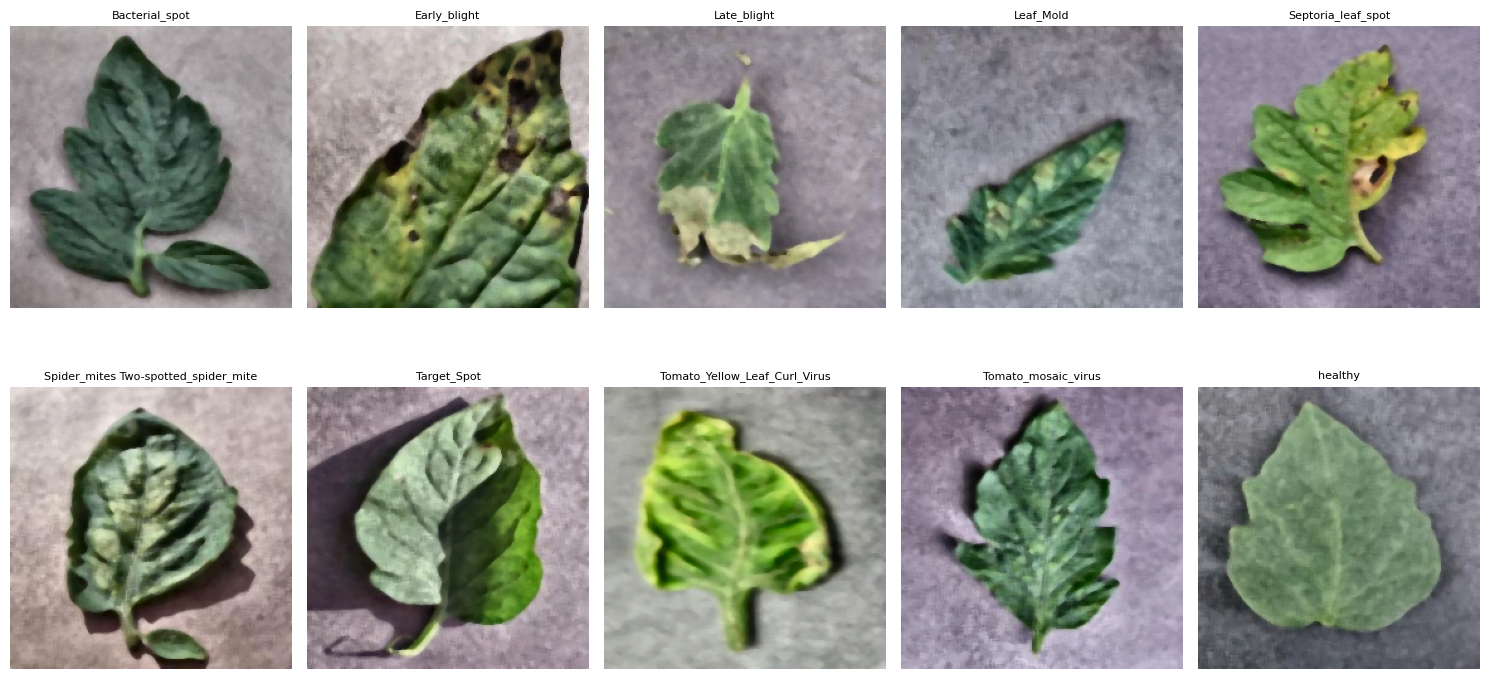

In [8]:
import cv2
import os
import matplotlib.pyplot as plt

IMG_SIZE = (224, 224)

# Create CLAHE object
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

plt.figure(figsize=(15, 8))

for i, class_name in enumerate(class_names):

    class_path = os.path.join(dataset_path, class_name)
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    # Read image
    img = cv2.imread(image_path)

    # Convert BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize
    img = cv2.resize(img, IMG_SIZE)

    # Apply Median Filter
    filtered_img = cv2.medianBlur(img, 5)

    # Convert to LAB color space
    lab = cv2.cvtColor(filtered_img, cv2.COLOR_RGB2LAB)

    # Split channels
    l, a, b = cv2.split(lab)

    # Apply CLAHE to the L channel
    l = clahe.apply(l)

    # Merge channels
    lab = cv2.merge((l, a, b))

    # Convert back to RGB
    clahe_img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    # Display
    plt.subplot(2, 5, i + 1)
    plt.imshow(clahe_img)
    plt.title(class_name.replace("Tomato___", ""), fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

# agumentation

In [9]:
import tensorflow as tf
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

print("✅ Data Augmentation Created Successfully!")

✅ Data Augmentation Created Successfully!


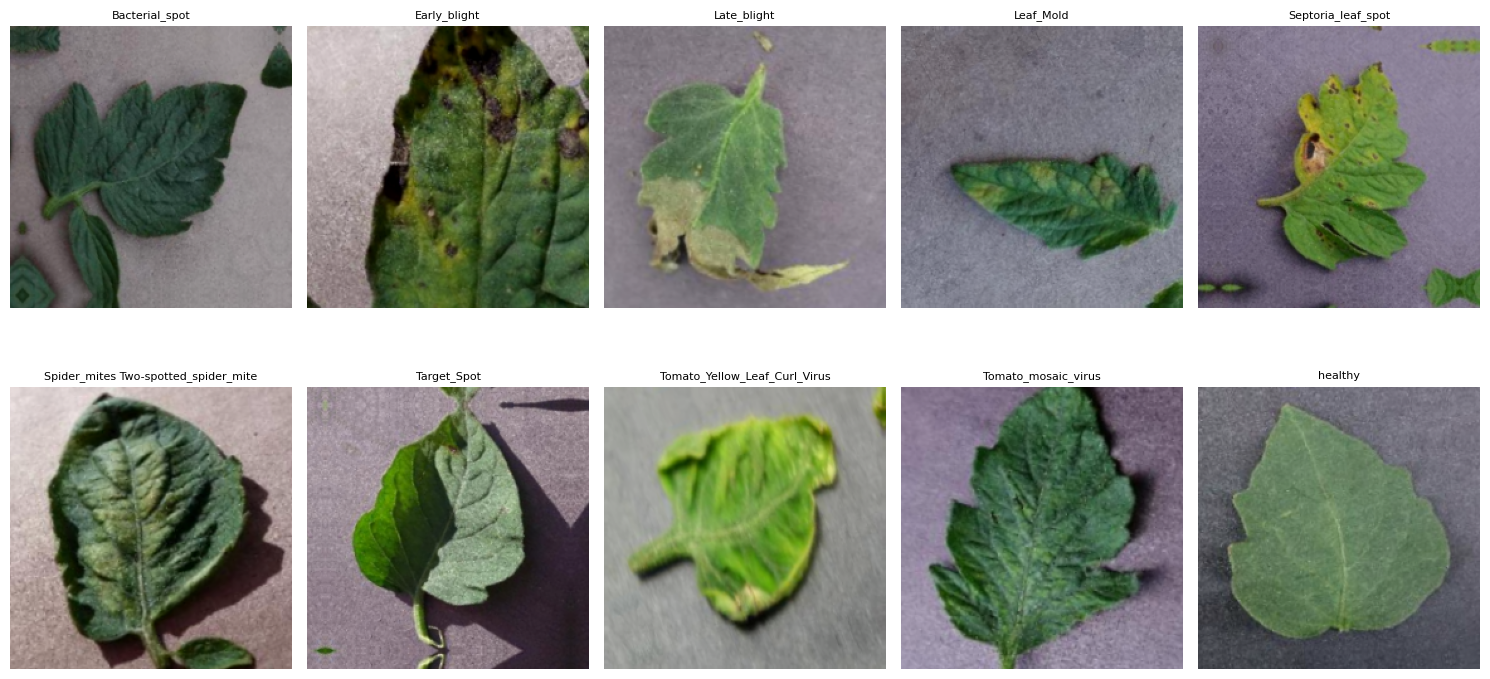

In [10]:
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
import os

IMG_SIZE = (224, 224)

plt.figure(figsize=(15, 8))

for i, class_name in enumerate(class_names):

    class_path = os.path.join(dataset_path, class_name)
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    # Read image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)

    # Convert to Tensor
    img_tensor = tf.convert_to_tensor(img, dtype=tf.float32)
    img_tensor = tf.expand_dims(img_tensor, axis=0)

    # Apply Augmentation
    augmented_img = data_augmentation(img_tensor)
    augmented_img = tf.squeeze(augmented_img)

    plt.subplot(2, 5, i + 1)
    plt.imshow(tf.cast(augmented_img, tf.uint8))
    plt.title(class_name.replace("Tomato___", ""), fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

# save folder

In [11]:
import os
import cv2
import tensorflow as tf
from tensorflow.keras import layers
from tqdm import tqdm

# Output folder
save_folder = r"C:\Users\anitt\OneDrive\Desktop\dl project\cute"
os.makedirs(save_folder, exist_ok=True)

# Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

# CLAHE
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

# Process each class
for class_name in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, class_name)

    if not os.path.isdir(class_path):
        continue

    save_class = os.path.join(save_folder, class_name)
    os.makedirs(save_class, exist_ok=True)

    for image_name in tqdm(os.listdir(class_path), desc=class_name):

        image_path = os.path.join(class_path, image_name)

        img = cv2.imread(image_path)

        if img is None:
            continue

        # Resize
        img = cv2.resize(img, (224,224))

        # Median Filter
        img = cv2.medianBlur(img, 5)

        # CLAHE
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        l = clahe.apply(l)
        lab = cv2.merge((l, a, b))
        img = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

        # Convert to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Augmentation
        img = tf.convert_to_tensor(img, dtype=tf.float32)
        img = tf.expand_dims(img, 0)

        aug_img = data_augmentation(img)
        aug_img = tf.squeeze(aug_img)
        aug_img = tf.clip_by_value(aug_img, 0, 255)
        aug_img = aug_img.numpy().astype("uint8")

        # Convert back to BGR
        aug_img = cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR)

        # Save image
        save_path = os.path.join(save_class, image_name)
        cv2.imwrite(save_path, aug_img)

print("✅ All preprocessing completed successfully!")
print("📁 Saved folder:", save_folder)

Tomato___Tomato_Yellow_Leaf_Curl_Virus: 100%|██████████████████████████████████████| 1000/1000 [02:35<00:00,  6.44it/s]


✅ All preprocessing completed successfully!
📁 Saved folder: C:\Users\anitt\OneDrive\Desktop\dl project\cute


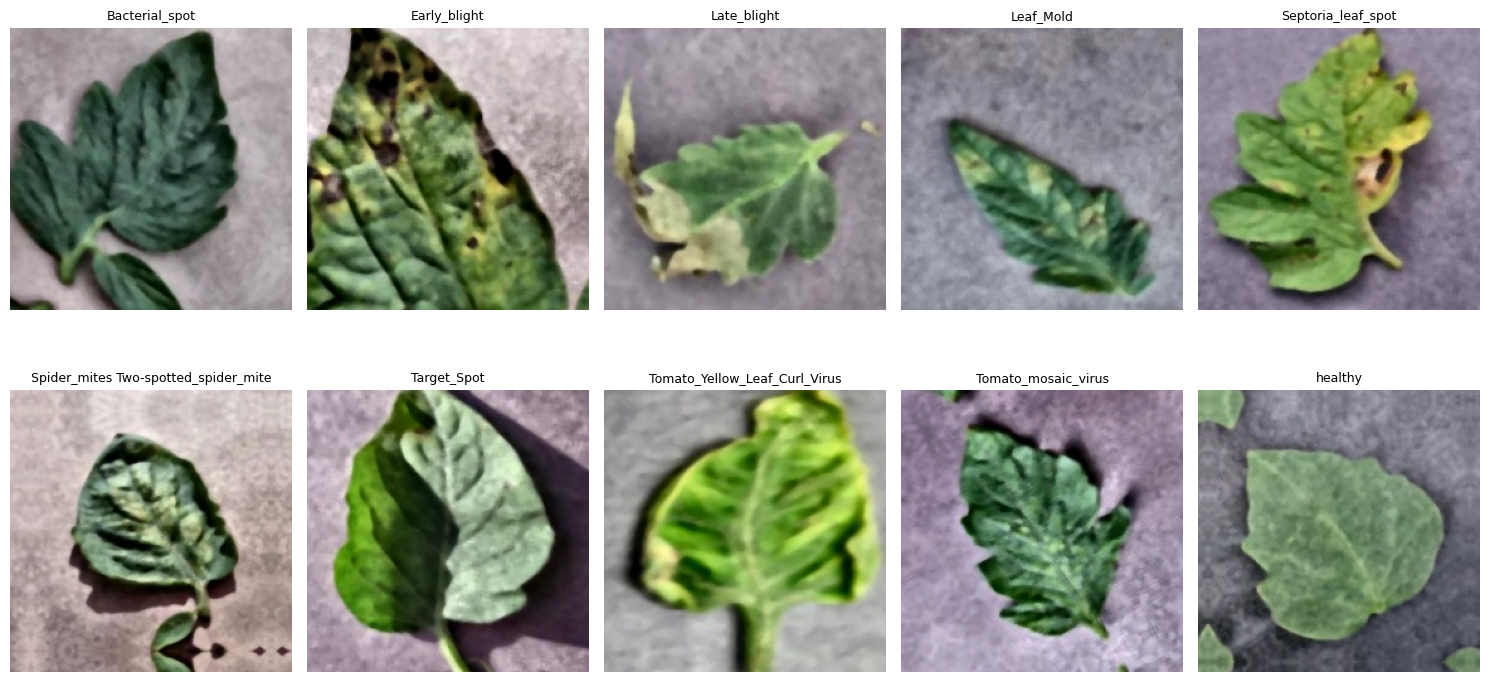

In [12]:
import os
import cv2
import matplotlib.pyplot as plt

# Path of saved preprocessed images
save_folder = r"C:\Users\anitt\OneDrive\Desktop\dl project\cute"
class_names = sorted(os.listdir(save_folder))

plt.figure(figsize=(15, 8))

for i, class_name in enumerate(class_names):

    class_path = os.path.join(save_folder, class_name)

    if not os.path.isdir(class_path):
        continue

    image_name = os.listdir(class_path)[0]   # First image
    image_path = os.path.join(class_path, image_name)

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(class_name.replace("Tomato___", ""), fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

# label encoding

In [13]:
import os
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [14]:
dataset_path= r"C:\Users\anitt\OneDrive\Desktop\dl project\cute"

image_paths = []
labels = []

for class_name in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, class_name)

    if not os.path.isdir(class_path):
        continue

    for image_name in os.listdir(class_path):

        image_paths.append(os.path.join(class_path, image_name))
        labels.append(class_name)

print("Total Images:", len(image_paths))
print("Total Labels:", len(labels))

Total Images: 10000
Total Labels: 10000


In [15]:
label_encoder = LabelEncoder()

encoded_labels = label_encoder.fit_transform(labels)

print("✅ Label Encoding Completed!")

✅ Label Encoding Completed!


In [16]:
mapping = pd.DataFrame({
    "Class Name": label_encoder.classes_,
    "Encoded Label": range(len(label_encoder.classes_))
})

print(mapping)

                                      Class Name  Encoded Label
0                        Tomato___Bacterial_spot              0
1                          Tomato___Early_blight              1
2                           Tomato___Late_blight              2
3                             Tomato___Leaf_Mold              3
4                    Tomato___Septoria_leaf_spot              4
5  Tomato___Spider_mites Two-spotted_spider_mite              5
6                           Tomato___Target_Spot              6
7         Tomato___Tomato_Yellow_Leaf_Curl_Virus              7
8                   Tomato___Tomato_mosaic_virus              8
9                               Tomato___healthy              9


In [17]:
import cv2
import numpy as np

X = []

for img_path in image_paths:
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    X.append(img)

X = np.array(X)
y = np.array(encoded_labels)

print("Image Shape:", X.shape)
print("Label Shape:", y.shape)

Image Shape: (10000, 224, 224, 3)
Label Shape: (10000,)


In [18]:
X

array([[[[171, 158, 165],
         [174, 161, 168],
         [177, 164, 171],
         ...,
         [167, 156, 160],
         [169, 158, 162],
         [169, 158, 162]],

        [[170, 157, 164],
         [172, 159, 166],
         [174, 161, 168],
         ...,
         [168, 157, 161],
         [170, 159, 163],
         [172, 161, 165]],

        [[169, 156, 163],
         [170, 157, 164],
         [171, 158, 165],
         ...,
         [169, 158, 162],
         [171, 160, 164],
         [174, 163, 167]],

        ...,

        [[ 20,  38,  22],
         [ 16,  34,  18],
         [ 14,  31,  15],
         ...,
         [157, 148, 151],
         [153, 144, 147],
         [150, 141, 144]],

        [[ 23,  46,  26],
         [ 21,  44,  24],
         [ 22,  43,  26],
         ...,
         [156, 147, 150],
         [152, 143, 146],
         [148, 139, 142]],

        [[ 32,  57,  36],
         [ 30,  55,  34],
         [ 32,  53,  36],
         ...,
         [154, 145, 148],
        

In [19]:
y

array([0, 0, 0, ..., 7, 7, 7], shape=(10000,))

# normalization

In [20]:
# Normalize pixel values from [0,255] to [0,1]

X = X.astype("float32") / 255.0

print("Normalization Completed Successfully!")
print("Minimum Pixel Value:", X.min())
print("Maximum Pixel Value:", X.max())
print("Data Type:", X.dtype)

Normalization Completed Successfully!
Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0
Data Type: float32


# train test split

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Images :", X_train.shape)
print("Test Images  :", X_test.shape)
print("Train Labels :", y_train.shape)
print("Test Labels  :", y_test.shape)

Train Images : (8000, 224, 224, 3)
Test Images  : (2000, 224, 224, 3)
Train Labels : (8000,)
Test Labels  : (2000,)


# mobilenet

In [22]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3),
    pooling='avg'
)

# Freeze the pretrained layers
base_model.trainable = False

print("✅ MobileNetV2 Loaded Successfully!")

✅ MobileNetV2 Loaded Successfully!


# extract features

In [23]:
# Extract features from training and testing images

X_train_features = base_model.predict(X_train, batch_size=32, verbose=1)
X_test_features = base_model.predict(X_test, batch_size=32, verbose=1)

print("Training Feature Shape:", X_train_features.shape)
print("Testing Feature Shape:", X_test_features.shape)

250/250 ━━━━━━━━━━━━━━━━━━━━ 397s 2s/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step
Training Feature Shape: (8000, 1280)
Testing Feature Shape: (2000, 1280)


## classification model

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train_features.shape[1],)),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(10, activation='softmax')   # 10 tomato classes
])

model.summary()

C:\Users\anitt\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │         655,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 789,770 (3.01 MB)

 Trainable params: 789,770 (3.01 MB)

 Non-trainable params: 0 (0.00 B)

# compile the model

In [25]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model Compiled Successfully!")

✅ Model Compiled Successfully!


# callbacks

In [26]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

# train model

In [27]:
history = model.fit(
    X_train_features,
    y_train,
    validation_data=(X_test_features, y_test),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.5228 - loss: 1.4015 - val_accuracy: 0.7200 - val_loss: 0.8310 - learning_rate: 0.0010
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.6821 - loss: 0.9165 - val_accuracy: 0.7685 - val_loss: 0.6809 - learning_rate: 0.0010
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.7237 - loss: 0.7983 - val_accuracy: 0.7770 - val_loss: 0.6507 - learning_rate: 0.0010
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.7519 - loss: 0.7231 - val_accuracy: 0.7850 - val_loss: 0.6426 - learning_rate: 0.0010
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.7794 - loss: 0.6505 - val_accuracy: 0.7965 - val_loss: 0.5794 - learning_rate: 0.0010
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.7896 - loss: 0.6053 - val_accuracy: 0.8130 - val_loss: 0.5500 - learning_rate: 0.0010
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.7976 - loss: 0

# evalate the model

In [28]:
test_loss, test_accuracy = model.evaluate(X_test_features, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8335 - loss: 0.4995
Test Loss: 0.49947264790534973
Test Accuracy: 0.8335000276565552


# plot accuracy and loss

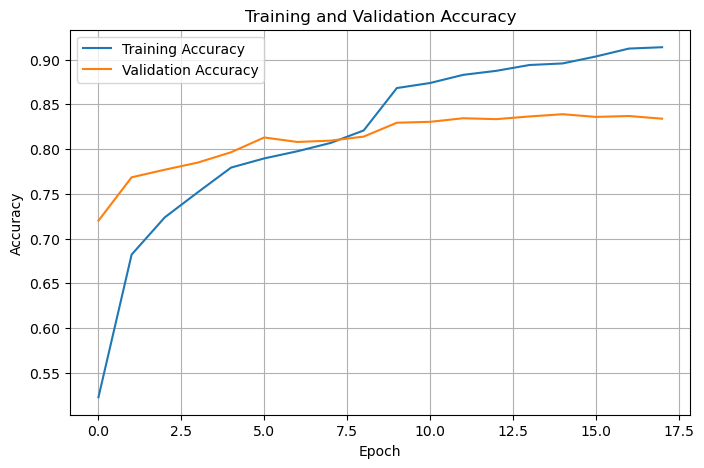

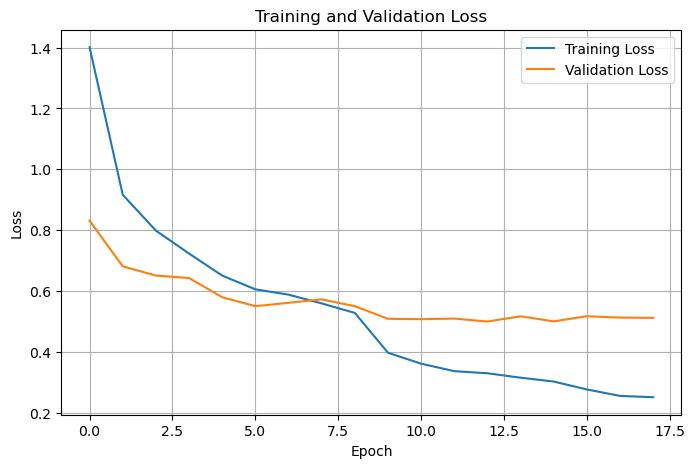

In [29]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss Graph
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [30]:
import numpy as np

# Predict class probabilities
y_pred = model.predict(X_test_features)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred, axis=1)

print("Prediction Shape:", y_pred.shape)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Prediction Shape: (2000,)


# confussion matrix

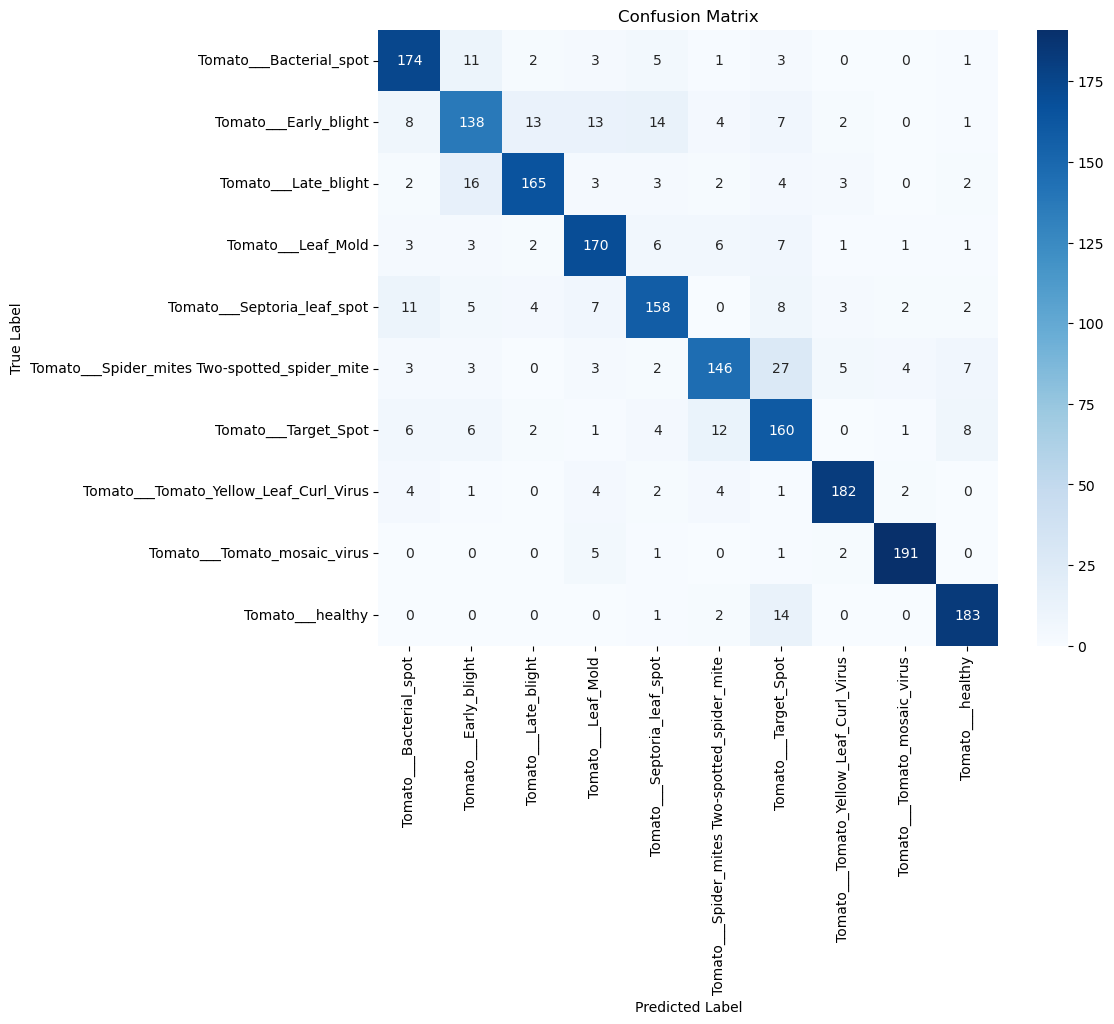

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# classification report

In [32]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.82      0.87      0.85       200
                        Tomato___Early_blight       0.75      0.69      0.72       200
                         Tomato___Late_blight       0.88      0.82      0.85       200
                           Tomato___Leaf_Mold       0.81      0.85      0.83       200
                  Tomato___Septoria_leaf_spot       0.81      0.79      0.80       200
Tomato___Spider_mites Two-spotted_spider_mite       0.82      0.73      0.77       200
                         Tomato___Target_Spot       0.69      0.80      0.74       200
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.92      0.91      0.91       200
                 Tomato___Tomato_mosaic_virus       0.95      0.95      0.95       200
                             Tomato___healthy       0.89      0.92      0.90       200

                                     accu

# model save

In [33]:
model.save("tomato_disease_mobilenetv2.keras")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [1]:
import gradio as gr
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications import MobileNetV2

# ==========================
# Load Trained Classifier
# ==========================

classifier = load_model("tomato_disease_mobilenetv2.keras")

# ==========================
# Load Feature Extractor
# ==========================

feature_extractor = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224,224,3)
)

feature_extractor.trainable = False

# ==========================
# Class Names
# ==========================

class_names = [
    "Tomato___Bacterial_spot",
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Tomato___Leaf_Mold",
    "Tomato___Septoria_leaf_spot",
    "Tomato___Spider_mites Two-spotted_spider_mite",
    "Tomato___Target_Spot",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato___Tomato_mosaic_virus",
    "Tomato___healthy"
]

# ==========================
# Disease Information
# ==========================

disease_info = {

    "Tomato___Bacterial_spot": {
        "description": "Bacterial disease causing dark spots on tomato leaves.",
        "prevention": "Use disease-free seeds and apply copper-based fungicides."
    },

    "Tomato___Early_blight": {
        "description": "Fungal disease causing concentric brown spots on leaves.",
        "prevention": "Remove infected leaves and spray fungicide."
    },

    "Tomato___Late_blight": {
        "description": "Serious disease causing dark lesions on leaves and fruits.",
        "prevention": "Avoid excess moisture and apply recommended fungicides."
    },

    "Tomato___Leaf_Mold": {
        "description": "Leaf mold causes yellow patches on leaves.",
        "prevention": "Reduce humidity and improve air circulation."
    },

    "Tomato___Septoria_leaf_spot": {
        "description": "Small circular brown spots appear on older leaves.",
        "prevention": "Remove infected leaves and use fungicides."
    },

    "Tomato___Spider_mites Two-spotted_spider_mite": {
        "description": "Tiny mites suck plant sap and damage leaves.",
        "prevention": "Spray miticide and maintain proper irrigation."
    },

    "Tomato___Target_Spot": {
        "description": "Brown circular spots develop on tomato leaves.",
        "prevention": "Use resistant varieties and fungicides."
    },

    "Tomato___Tomato_Yellow_Leaf_Curl_Virus": {
        "description": "Virus causing yellow curled leaves and stunted growth.",
        "prevention": "Control whiteflies and remove infected plants."
    },

    "Tomato___Tomato_mosaic_virus": {
        "description": "Virus causing mosaic patterns on tomato leaves.",
        "prevention": "Use clean tools and resistant varieties."
    },

    "Tomato___healthy": {
        "description": "The tomato leaf is healthy and free from disease.",
        "prevention": "Continue proper watering and regular monitoring."
    }

}

# ==========================
# Prediction Function
# ==========================

def predict(image):

    image = cv2.resize(image, (224,224))
    image = image.astype("float32") / 255.0
    image = np.expand_dims(image, axis=0)

    features = feature_extractor.predict(image, verbose=0)

    prediction = classifier.predict(features, verbose=0)

    predicted_index = np.argmax(prediction)
    predicted_class = class_names[predicted_index]

    confidence = min(float(np.max(prediction) * 100), 99.99)

    description = disease_info[predicted_class]["description"]
    prevention = disease_info[predicted_class]["prevention"]

    disease_name = predicted_class.replace("Tomato___","").replace("_"," ")

    return f"""
🍅 TOMATO DISEASE DETECTION RESULT

✅ Disease:
{disease_name}

📊 Confidence:
{confidence:.2f} %

📝 Description:
{description}

💡 Prevention:
{prevention}
"""

# ==========================
# Gradio Interface
# ==========================

interface = gr.Interface(

    fn=predict,

    inputs=gr.Image(type="numpy", label="Upload Tomato Leaf Image"),

    outputs=gr.Textbox(label="Prediction Result"),

    title="🍅 AI-Based Tomato Leaf Disease Detection System",

    description="""
Upload a tomato leaf image.

This AI model will:

✅ Detect the disease

✅ Display confidence score

✅ Show disease description

✅ Suggest prevention methods
""",

    article="""
---
### 👩‍💻 Developed By
**Y Anitt Ajitha**

**Internship Project - 2026**

**Deep Learning Model: MobileNetV2**
"""
)

interface.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
